In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

In [6]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("data.csv")

Saving data.csv to data (1).csv


In [7]:
if "Unnamed: 32" in df.columns:
    df = df.drop(columns=["Unnamed: 32"])

if "id" in df.columns:
    df = df.drop(columns=["id"])

df["diagnosis"] = df["diagnosis"].map({"M": 1, "B": 0})

df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [8]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("Features and target created successfully.")
print("X shape:", X.shape)
print("y shape:", y.shape)

Features and target created successfully.
X shape: (569, 30)
y shape: (569,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed successfully.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Train-test split completed successfully.
X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Standard scaling completed successfully.")
print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

Standard scaling completed successfully.
X_train_scaled shape: (455, 30)
X_test_scaled shape: (114, 30)


In [11]:
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)
print("y_train :", y_train.shape)
print("y_test :", y_test.shape)

svm_rbf = SVC(kernel="rbf", probability=True, random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

print("SVM (RBF kernel) training completed.")

X_train_scaled: (455, 30)
X_test_scaled : (114, 30)
y_train : (455,)
y_test : (114,)
SVM (RBF kernel) training completed.


In [12]:
y_pred_svm = svm_rbf.predict(X_test_scaled)
accuracy_svm = accuracy_score(y_test, y_pred_svm)

print("Predictions on test data generated.")
print("SVM Accuracy on test set:", round(accuracy_svm, 4))

print("\nClassification Report (SVM):")
print(classification_report(y_test, y_pred_svm, target_names=["Benign (0)", "Malignant (1)"]))

Predictions on test data generated.
SVM Accuracy on test set: 0.9737

Classification Report (SVM):
               precision    recall  f1-score   support

   Benign (0)       0.96      1.00      0.98        72
Malignant (1)       1.00      0.93      0.96        42

     accuracy                           0.97       114
    macro avg       0.98      0.96      0.97       114
 weighted avg       0.97      0.97      0.97       114



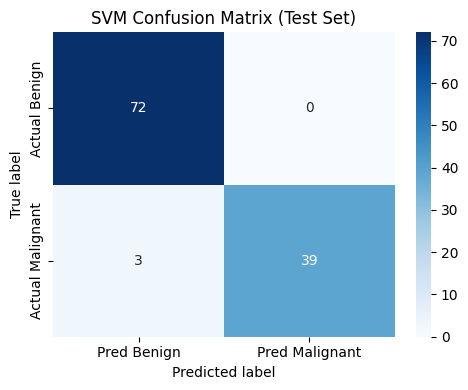

In [13]:
cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Benign", "Pred Malignant"],
    yticklabels=["Actual Benign", "Actual Malignant"]
)
plt.title("SVM Confusion Matrix (Test Set)")
plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

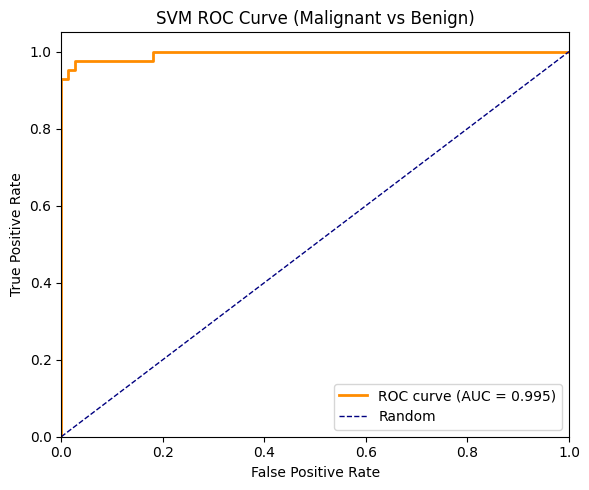

ROC-AUC for SVM: 0.9947


In [14]:
y_scores_svm = svm_rbf.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_svm)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr,
    tpr,
    color="darkorange",
    lw=2,
    label=f"ROC curve (AUC = {roc_auc:.3f})"
)
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve (Malignant vs Benign)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("ROC-AUC for SVM:", round(roc_auc, 4))

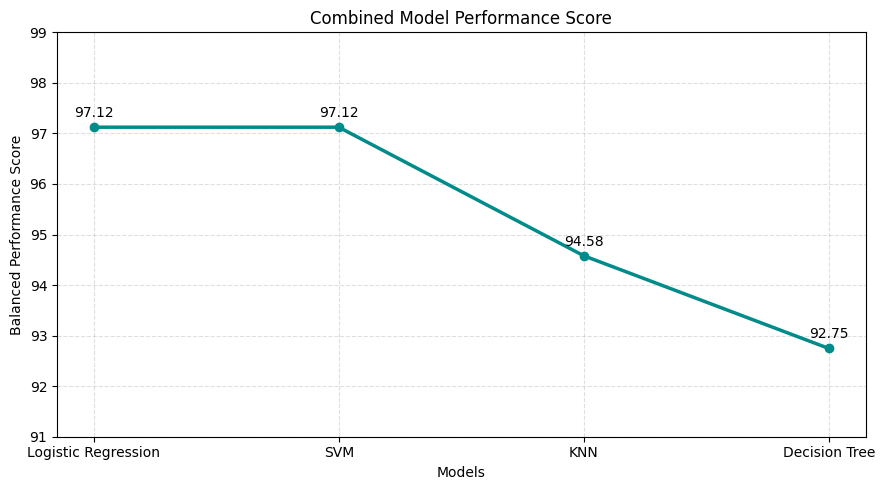

In [15]:
models = ["Logistic Regression", "SVM", "KNN", "Decision Tree"]

accuracy = [97.37, 97.37, 94.74, 98.24]
f1_benign = [0.98, 0.98, 0.96, 0.93]
f1_malignant = [0.96, 0.96, 0.93, 0.87]

combined_score = [
    (a + b * 100 + m * 100) / 3
    for a, b, m in zip(accuracy, f1_benign, f1_malignant)
]

plt.figure(figsize=(9, 5))
plt.plot(models, combined_score, marker="o", linewidth=2.5, color="darkcyan")

for i, value in enumerate(combined_score):
    plt.text(i, value + 0.2, f"{value:.2f}", ha="center", fontsize=10)

plt.title("Combined Model Performance Score")
plt.xlabel("Models")
plt.ylabel("Balanced Performance Score")
plt.ylim(91, 99)
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

In [16]:
def get_recommendation(prob):
    if prob < 0.30:
        return "Low risk - likely benign, but medical confirmation is advised."
    elif prob < 0.70:
        return "Moderate risk - further medical review is recommended."
    else:
        return "High risk - urgent clinical evaluation is strongly recommended."


sample_indices = [0, 5, 10, 20, 30]

selected_inputs = X_test.iloc[sample_indices]
selected_inputs_scaled = scaler.transform(selected_inputs)

pred_labels = svm_rbf.predict(selected_inputs_scaled)
pred_probs = svm_rbf.predict_proba(selected_inputs_scaled)[:, 1]

results = pd.DataFrame({
    "Patient Index": selected_inputs.index,
    "Predicted Diagnosis": ["Malignant" if p == 1 else "Benign" for p in pred_labels],
    "Cancer Probability": [round(prob, 4) for prob in pred_probs],
    "Recommendation": [get_recommendation(prob) for prob in pred_probs]
})

results

,Patient Index,Predicted Diagnosis,Cancer Probability,Recommendation
0,120,Benign,0.0016,"Low risk - likely benign, but medical confirma..."
1,318,Benign,0.0272,"Low risk - likely benign, but medical confirma..."
2,479,Malignant,0.9582,High risk - urgent clinical evaluation is stro...
3,459,Benign,0.0024,"Low risk - likely benign, but medical confirma..."
4,70,Malignant,1.0000,High risk - urgent clinical evaluation is stro...


In [20]:
def predict_patient(features_row, patient_name="Patient"):
    scaled = scaler.transform(features_row)
    prob = svm_rbf.predict_proba(scaled)[:, 1][0]
    label = svm_rbf.predict(scaled)[0]

    diagnosis = "Malignant" if label == 1 else "Benign"

    if prob < 0.30:
        risk_level = "Low Risk"
        recommendation = "Likely benign, but medical confirmation is advised."
    elif prob < 0.70:
        risk_level = "Moderate Risk"
        recommendation = "Further medical review is recommended."
    else:
        risk_level = "High Risk"
        recommendation = "Urgent clinical evaluation is strongly recommended."

    print("\n--- Prediction Result ---")
    print(f"Patient Name : {patient_name}")
    print(f"Predicted Diagnosis : {diagnosis}")
    print(f"Cancer Probability : {prob * 100:.2f}%")
    print(f"Risk Level : {risk_level}")
    print(f"Recommendation : {recommendation}")
    print("-------------------------")

In [23]:
example_patient = X_test.iloc[[0]]
predict_patient(example_patient, "Sample Patient 1")


--- Prediction Result ---
Patient Name : Sample Patient 1
Predicted Diagnosis : Benign
Cancer Probability : 0.16%
Risk Level : Low Risk
Recommendation : Likely benign, but medical confirmation is advised.
-------------------------


In [22]:
base_patient = X_test.iloc[[0]]

predict_patient(base_patient, "Original Patient")

predict_patient(
    base_patient.assign(radius_mean=base_patient["radius_mean"] - 2),
    "radius_mean decreased by 2"
)

predict_patient(
    base_patient.assign(radius_mean=base_patient["radius_mean"] + 2),
    "radius_mean increased by 2"
)


--- Prediction Result ---
Patient Name : Original Patient
Predicted Diagnosis : Benign
Cancer Probability : 0.16%
Risk Level : Low Risk
Recommendation : Likely benign, but medical confirmation is advised.
-------------------------

--- Prediction Result ---
Patient Name : radius_mean decreased by 2
Predicted Diagnosis : Benign
Cancer Probability : 0.18%
Risk Level : Low Risk
Recommendation : Likely benign, but medical confirmation is advised.
-------------------------

--- Prediction Result ---
Patient Name : radius_mean increased by 2
Predicted Diagnosis : Benign
Cancer Probability : 0.17%
Risk Level : Low Risk
Recommendation : Likely benign, but medical confirmation is advised.
-------------------------
